# 24_model_forecasting_JIW

- 목적: 정상 데이터로 '다음 샘플 예측' 모델을 학습하고, 예측 오차를 이상점수로 써서 21 규칙 베이스라인과 같은 계약으로 비교한다.
- 입력: `data/raw`(없으면 zip 자동 추출) → `preprocess.preprocess()`, `data/processed/11_window_features.parquet`(윈도우 목록·분할·state)
- 출력: `figures/24_model_forecasting_JIW/`, `results/24_model_forecasting_JIW/`(metrics.csv · cv_scores.csv · error_cases.csv), `models/24_model_forecasting_JIW/`(가중치, git 제외)
- 담당: JIW
- 탐지 대상: 모터-펌프 구동부 이상 (가이드북은 센서를 "유압펌프 상/하단"에 설치했다고 쓰지만 유압 유닛이 모터-펌프 일체형이라 진동 센서의 정확한 부착 부위를 알 수 없어 펌프/모터 원인을 구분할 수 없음, 착수 가이드 머리말)
- 심사 대응: 2번(모델 비교), 3번(FP 운전 상태·FN 세그먼트), 5번(합성 이상 주입 평가), 6번(재현성: 가중치 재사용·시드 고정)

파일명 규칙: 0x 진단 · 1x 전처리·피처 · 2x 모델 · 3x 분석

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
import paths
NB = "24_model_forecasting_JIW"  # 파일명(확장자 제외)과 같게
FIG, RES = paths.nb_dirs(NB)
SEED = 42
np.random.seed(SEED)
import benchmark_jiw as B

KEYS = ['cnn_deepant', 'lstm_ad']
WIN_LIST = (1.0, 2.0)      # 착수 가이드 §2: 1~3초. 21 smoke(1초)와 지연 비교용 1초 + 사전 비교 기준 2초
SEEDS = (0, 1, 2)
EPOCHS = 30
LOOKBACK = 5               # 0.5초
RETRAIN = False            # models/24_model_forecasting_JIW/ 가중치가 있으면 불러와 평가만 한다
PROGRESS = False           # 터미널 실행 시 True면 tqdm 진행 막대 표시
print(NB, FIG.relative_to(ROOT), RES.relative_to(ROOT))

24_model_forecasting_JIW figures\24_model_forecasting_JIW results\24_model_forecasting_JIW


## 1. 모델

| 모델 | 구조 | 이상점수 |
|---|---|---|
| CNN (DeepAnT) | Conv1d 2층 → MaxPool → FC, 과거 0.5초(5샘플)로 다음 샘플 3채널 예측 | 채널별 예측 오차를 train 오차 표준편차로 나눈 제곱 평균 |
| LSTM-AD | 2층 LSTM(hidden 32) → 선형, 과거 0.5초로 다음 샘플 예측 | 위와 동일 |

- 계열 근거: KDD'25 서베이 분류(Prediction-based → Forecasting), TSB-AD 다변량 VUS-PR 원 순위 CNN 1위(0.31) · LSTM-AD 0.31.
- 윈도우 점수 = 윈도우 안 시점 점수의 평균. 시점 점수는 세그먼트 시작 후 0.5초가 지난 샘플부터 정의되므로 1초 윈도우에서도 첫 윈도우가 채점된다.
- 이 전류는 60 Hz가 0.6 Hz로 접힌 규칙적 파형(자기상관 0.93)이라 정상은 예측이 쉽고, 파형이 흐트러지면 오차가 커진다는 가정이다.

평가 계약(`docs/modeling_kickoff.md`): 입력 = 표준 전처리 결과, 분할 = `group_kfold_seg`(fold 0~4) · `time_block`(k=1~4), 임계 = train 정상 점수 q99, 지표 = `evaluate` 공통 함수. 학습은 정상 윈도우가 속한 세그먼트만 쓴다.

In [2]:
segs, W = B.load_inputs()
cov = W.groupby(["win_s", "label"]).size().unstack().rename(columns={0: "정상 윈도우", 1: "이상 윈도우"})
cov["이상 세그먼트(윈도우 있음)"] = W[W.label == 1].groupby("win_s")["seg_uid"].nunique()
print("세그먼트", len(segs)); cov.loc[list(WIN_LIST)]

세그먼트 620


label,정상 윈도우,이상 윈도우,이상 세그먼트(윈도우 있음)
win_s,,,
1.0,3264,96,17
2.0,2254,63,13


## 2. 학습·평가 (윈도우 × 분할 × 시드)

판정 불가(세그먼트 길이 < 윈도우) 이상 세그먼트 비율은 1초 19.05%, 2초 38.10%다(착수 가이드 §2).

In [3]:
cv, err, sc = B.run(KEYS, NB, win_list=WIN_LIST, seeds=SEEDS, epochs=EPOCHS, lookback=LOOKBACK,
                    retrain=RETRAIN, progress=PROGRESS, segs=segs, W=W)
metrics = B.to_metrics(cv)
metrics.to_csv(RES / "metrics.csv", index=False)
cv.to_csv(RES / "cv_scores.csv", index=False)
err.to_csv(RES / "error_cases.csv", index=False)
print(cv["status"].value_counts().to_dict(), "runs", len(cv))
metrics[metrics["fold"] == "mean"].round(4)

{'loaded': 63, 'trained': 45} runs 108


,model,split,fold,auc,fpr_sample,fpr_segment,delay_median_s,win_s,thr,n_out_seg,n_detected,felt_delay_median_s
36,cnn_deepant_w1s,group_kfold_seg,mean,0.9999,0.0156,0.0317,0.9,1.0,3.7574,3.4,3.4,8.858
37,lstm_ad_w1s,group_kfold_seg,mean,0.9998,0.0145,0.0349,0.9,1.0,3.6894,3.4,3.4,8.858
38,cnn_deepant_w1s,time_block,mean,0.9999,0.0137,0.0387,0.9,1.0,3.5870,17.0,17.0,8.858
39,lstm_ad_w1s,time_block,mean,0.9997,0.0131,0.0335,0.9,1.0,3.5013,17.0,17.0,8.858
40,cnn_deepant_w2s,group_kfold_seg,mean,1.0000,0.0148,0.0285,1.9,2.0,3.4768,2.6,2.6,9.858
41,lstm_ad_w2s,group_kfold_seg,mean,1.0000,0.0146,0.0255,1.9,2.0,3.4234,2.6,2.6,9.858
42,cnn_deepant_w2s,time_block,mean,1.0000,0.0083,0.0179,1.9,2.0,3.4280,13.0,13.0,9.858
43,lstm_ad_w2s,time_block,mean,1.0000,0.0094,0.0167,1.9,2.0,3.4908,13.0,13.0,9.858


## 3. 요약 (fold·시드 평균)

`fpr_high_load`·`fpr_low_load`는 정상 윈도우의 운전 상태별 오경보율(state 0 = 고부하, 1 = 저부하), `inj_mean`은 합성 이상 탐지율(4유형 × 강도 0.25·0.5·1·2 평균).

In [4]:
B.summary(cv)

,,,auc,fpr_sample,fpr_segment,recall_window,n_detected,n_out_seg,delay_median_s,fpr_high_load,fpr_low_load,inj_mean
model,win_s,split,,,,,,,,,,
CNN (DeepAnT),1.0,group_kfold_seg,1.0,0.016,0.032,1.000,3.4,3.4,0.9,0.033,0.001,0.250
LSTM-AD,1.0,group_kfold_seg,1.0,0.014,0.035,1.000,3.4,3.4,0.9,0.031,0.001,0.250
CNN (DeepAnT),1.0,time_block,1.0,0.014,0.039,1.000,17.0,17.0,0.9,0.030,0.001,0.254
LSTM-AD,1.0,time_block,1.0,0.013,0.034,0.994,17.0,17.0,0.9,0.032,0.000,0.225
CNN (DeepAnT),2.0,group_kfold_seg,1.0,0.015,0.028,1.000,2.6,2.6,1.9,0.032,0.001,0.303
LSTM-AD,2.0,group_kfold_seg,1.0,0.015,0.026,1.000,2.6,2.6,1.9,0.032,0.000,0.295
CNN (DeepAnT),2.0,time_block,1.0,0.008,0.018,1.000,13.0,13.0,1.9,0.022,0.000,0.314
LSTM-AD,2.0,time_block,1.0,0.009,0.017,1.000,13.0,13.0,1.9,0.026,0.000,0.282


21 규칙 베이스라인(`results/21_model_rule_baseline_CHS/metrics.csv`)과 같은 윈도우·분할의 fold 평균 비교. rule1 = AI0 RMS 크기, rule3 = 상태별 RMS × 방향(21의 최강 규칙).

In [5]:
cols = ["model", "win_s", "split", "auc", "fpr_sample", "fpr_segment", "delay_median_s", "n_detected", "n_out_seg"]
ref = B.baseline_table()
ref = ref[ref["model"].isin(B.BASELINE_RULES) & ref["win_s"].isin(WIN_LIST)][cols]
mine = metrics[metrics["fold"] == "mean"][cols]
pd.concat([ref, mine]).sort_values(["win_s", "split", "auc"], ascending=[True, True, False]).round(4).reset_index(drop=True)

,model,win_s,split,auc,fpr_sample,fpr_segment,delay_median_s,n_detected,n_out_seg
0,cnn_deepant_w1s,1.0,group_kfold_seg,0.9999,0.0156,0.0317,0.90,3.4,3.4
1,lstm_ad_w1s,1.0,group_kfold_seg,0.9998,0.0145,0.0349,0.90,3.4,3.4
2,rule3_rms_state_dir,1.0,group_kfold_seg,0.8696,0.0138,0.0358,0.95,2.8,3.4
3,rule1_rms_ai0,1.0,group_kfold_seg,0.7864,0.0109,0.0395,0.95,2.8,3.4
4,cnn_deepant_w1s,1.0,time_block,0.9999,0.0137,0.0387,0.90,17.0,17.0
5,lstm_ad_w1s,1.0,time_block,0.9997,0.0131,0.0335,0.90,17.0,17.0
6,rule3_rms_state_dir,1.0,time_block,0.8686,0.0070,0.0187,0.90,14.0,17.0
7,rule1_rms_ai0,1.0,time_block,0.7786,0.0116,0.0384,0.90,14.0,17.0
8,cnn_deepant_w2s,2.0,group_kfold_seg,1.0000,0.0148,0.0285,1.90,2.6,2.6
9,lstm_ad_w2s,2.0,group_kfold_seg,1.0000,0.0146,0.0255,1.90,2.6,2.6


## 4. 그림

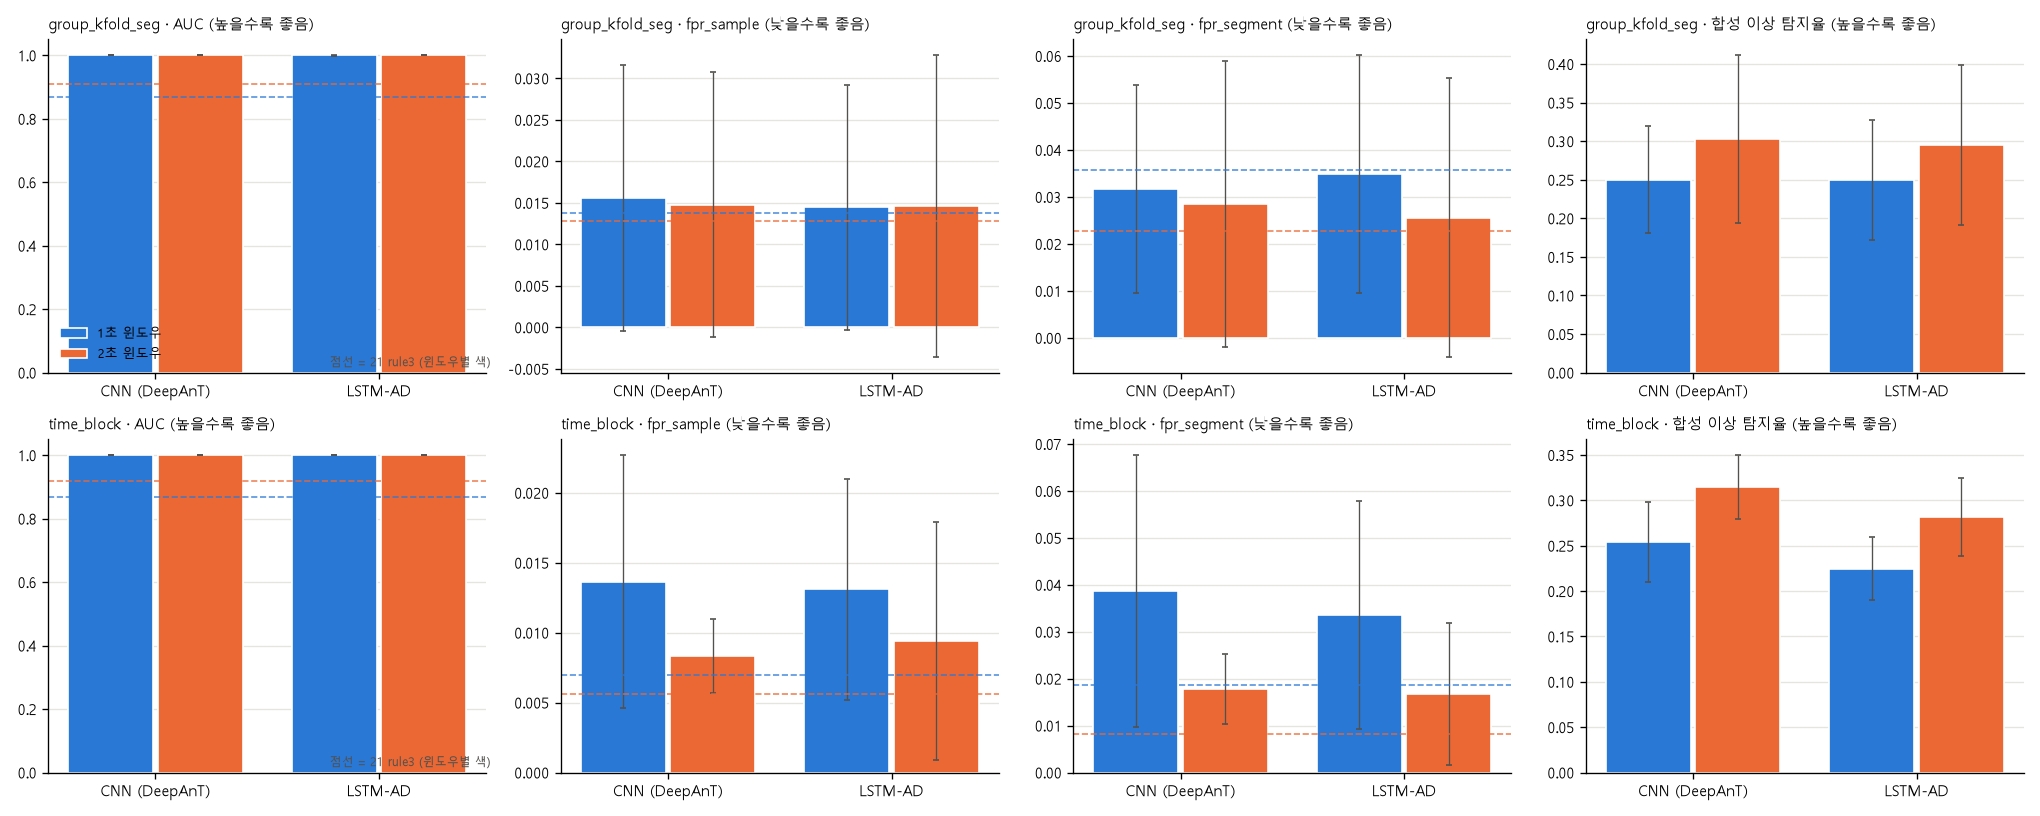

In [6]:
B.plot_overview(cv, FIG); display(Image(FIG / "metrics_overview.png"))

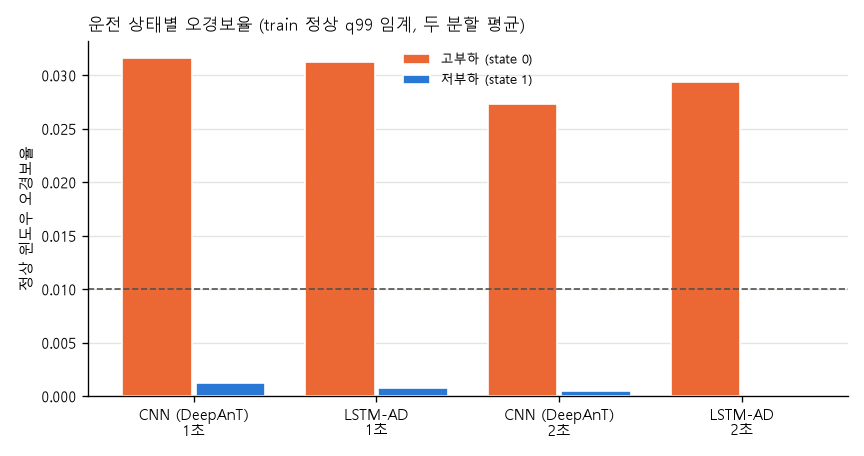

In [7]:
B.plot_state_fpr(cv, FIG); display(Image(FIG / "fpr_by_state.png"))

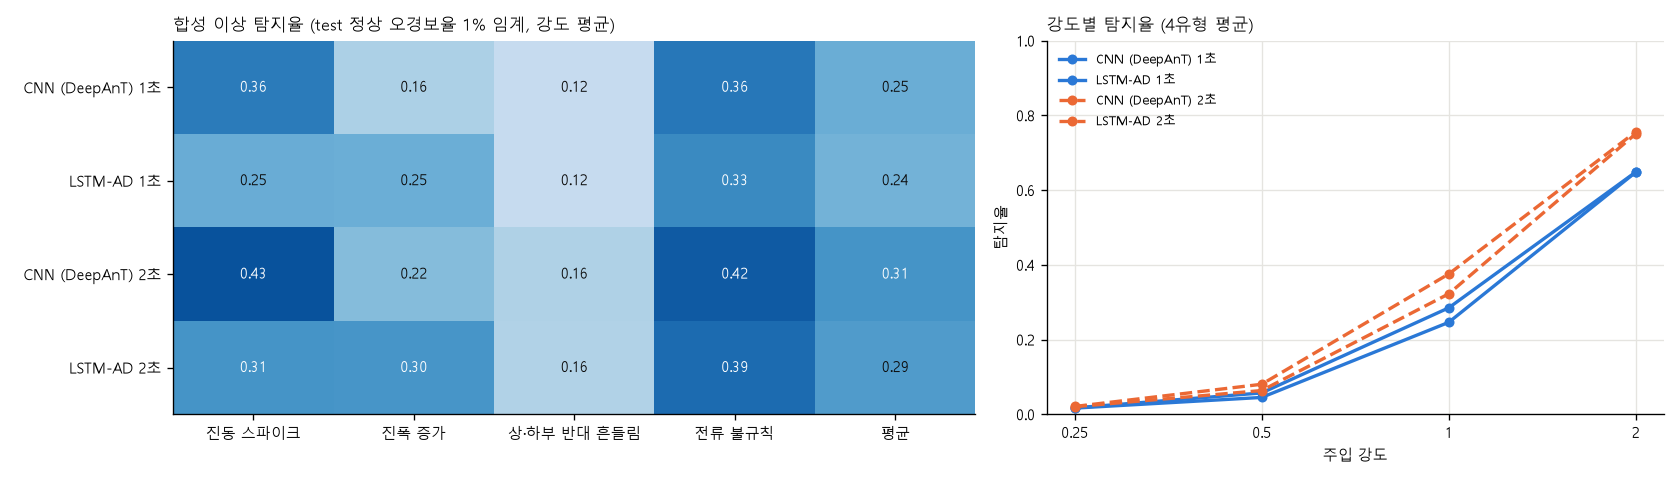

In [8]:
B.plot_injection(cv, FIG); display(Image(FIG / "injection.png"))

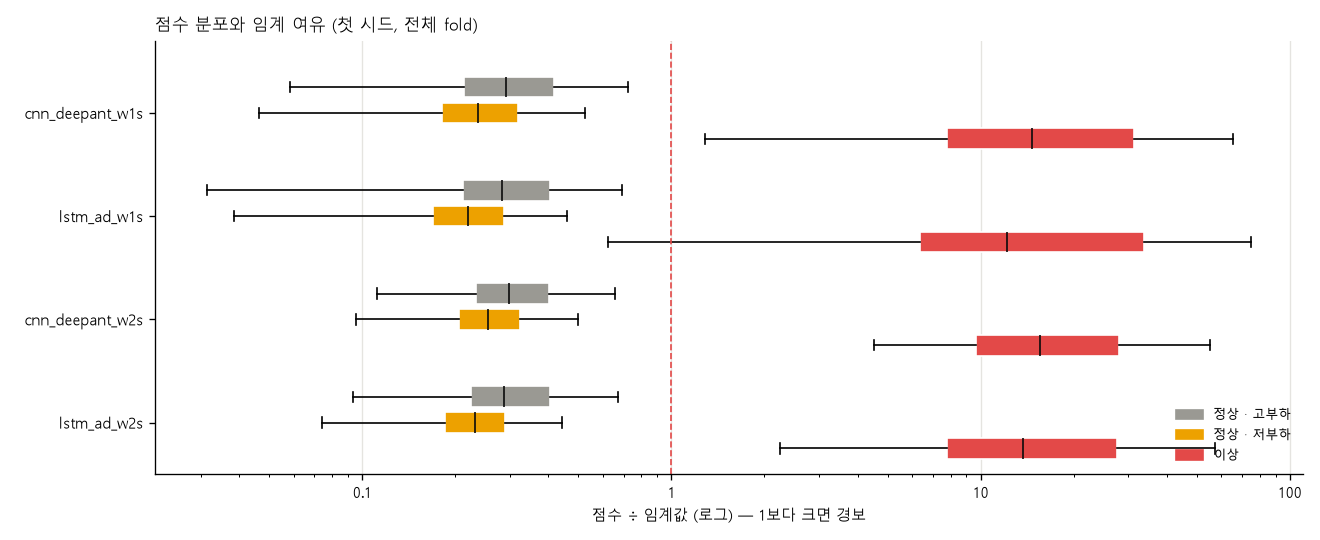

In [9]:
B.plot_score_margin(sc, FIG); display(Image(FIG / "score_margin.png"))

## 5. 오류 사례 (첫 시드)

FP = 초과 윈도우가 1개라도 있는 정상 세그먼트, FN = 한 번도 초과하지 않은 이상 세그먼트. 31 오류분석 노트북의 입력으로 쓴다.

In [10]:
fp = err[err["type"] == "FP"].groupby(["model_id", "state"]).size().unstack(fill_value=0)
fn = err[err["type"] == "FN"].groupby(["model_id", "seg_uid"]).size().unstack(fill_value=0) if (err["type"] == "FN").any() else pd.DataFrame()
display(fp.rename(columns=lambda c: f"FP 세그먼트({c})"))
fn

state,FP 세그먼트(고부하),FP 세그먼트(저부하)
model_id,,
cnn_deepant_w1s,34,4
cnn_deepant_w2s,17,1
lstm_ad_w1s,34,3
lstm_ad_w2s,17,0


""


## 6. 해석

발견 → 시사점 → 활용 아이디어는 `reports/24_model_forecasting_JIW.md`에 정리했다.